# **MSC Cell Counting Pipeline**
### Brightfield Microscopy Analysis

This notebook develops an automated pipeline to count mesenchymal stem cells (MSCs) from brightfield microscopy images acquired on a Cytation5 imaging system.

The dataset contains 40 images spanning three MSC cell lines (AD, BM, UC), two wells per line, six timepoints (4–34h), and four no-growth control images.

The pipeline covers:
- Preprocessing (well masking, background correction, normalisation)
- Cell detection and segmentation (classical CV + Cellpose comparison)
- Two complementary metrics: object count and confluence (%)
- Quality control flags and biological validation
- Growth rate and doubling time analysis

# 0. Setup
## 0.1 Imports

In [ ]:
# Core image processing
import tifffile
import numpy as np
from pathlib import Path
import xml.etree.ElementTree as ET

# Data manipulation
import pandas as pd
from scipy.optimize import curve_fit
from scipy import ndimage

# Classical CV
from skimage import filters, morphology, measure, segmentation, exposure
from skimage.feature import peak_local_max

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")

print("All imports successful")

All imports successful


## 0.2 Configuration

All pipeline parameters are defined here for transparency and reproducibility.
Physical scale constants are derived from the TIFF XML acquisition metadata (verified in Section 1.3): all 40 images share identical acquisition settings.

MSC size thresholds are grounded in published biology:
MSCs in suspension measure approximately 10–40 μm in diameter (Bianconi et al., 2013; Zimmermann et al., 2003).
These are converted to pixel radii using the instrument's physical scale.

In [32]:
# ── Paths ─────────────────────────────────────────────────────────────────────
IMAGE_DIR = Path("/Users/yuhyunkim/Documents/2_Job Related/25-26/Data Analytics/MULTUS-MLintern-20260416/task/images")

# ── Physical scale (from TIFF XML metadata) ───────────────────────────────────
# ImageWidthMicrons / PixelWidth = 3474.0 / 1992 ≈ 1.744 μm/px
# Consistent across all 40 images — verified in Section 1.3
MICRONS_PER_PIXEL = 3474.0 / 1992

# ── MSC size filter ───────────────────────────────────────────────────────────
# MSCs are typically 10–40 μm in diameter in suspension (literature-grounded)
# Used to exclude debris (too small) and cell clusters (too large)
MSC_MIN_DIAMETER_UM = 10   # μm
MSC_MAX_DIAMETER_UM = 40   # μm
MSC_MIN_AREA_PX = int(np.pi * (MSC_MIN_DIAMETER_UM / MICRONS_PER_PIXEL / 2) ** 2)
MSC_MAX_AREA_PX = int(np.pi * (MSC_MAX_DIAMETER_UM / MICRONS_PER_PIXEL / 2) ** 2)

# ── Morphology filter ─────────────────────────────────────────────────────────
# Adherent MSCs (spindle-shaped) have high eccentricity
# Suspended cells (round) and debris have low eccentricity
# Threshold based on literature: spindle-shaped cells typically eccentricity > 0.7
MIN_ECCENTRICITY = 0.7

# ── Confluence threshold ──────────────────────────────────────────────────────
# Above this confluence, individual cell counting becomes unreliable
# watershed segmentation degrades when cells are highly overlapping
HIGH_CONFLUENCE_THRESHOLD = 80  # %

print(f"Microns per pixel:     {MICRONS_PER_PIXEL:.3f} μm/px")
print(f"MSC area filter:       {MSC_MIN_AREA_PX}–{MSC_MAX_AREA_PX} px²")
print(f"Min eccentricity:      {MIN_ECCENTRICITY}")
print(f"High confluence flag:  >{HIGH_CONFLUENCE_THRESHOLD}%")

Microns per pixel:     1.744 μm/px
MSC area filter:       25–413 px²
Min eccentricity:      0.7
High confluence flag:  >80%


# 1. Data Loading

## 1.1 Metadata Parsing Functions

Each image carries two sources of metadata:

**Filename** (e.g. `AD-E1-t04.tif`): encodes cell line, well location, and timepoint.
These are the primary experimental variables and are not available elsewhere.

**TIFF XML tag (ImageDescription)**: embedded by the Cytation5 acquisition software (Gen5 v3.14).
Contains instrument settings (objective, LED intensity, camera gain, temperature) 
and physical scale (μm/pixel). All images share identical acquisition settings,
confirming a controlled, consistent experiment.

No-growth images (`noGrowth1–4.tif`) follow a different naming convention and carry
no timepoint information — they are flagged separately for exclusion from growth analysis.

In [33]:
def parse_filename(filepath):
    """
    Extract cell line, well, and timepoint from filename.
    e.g. AD-E1-t04.tif -> ('AD', 'E1', 4)
    Returns (None, None, None) for no-growth images.
    """
    name = filepath.stem
    if name.startswith("noGrowth"):
        return None, None, None
    parts     = name.split("-")
    cell_line = parts[0]
    well      = parts[1]
    timepoint = int(parts[2][1:])
    return cell_line, well, timepoint


def parse_tiff_metadata(filepath):
    """
    Extract acquisition metadata from the TIFF ImageDescription XML tag (tag 270).
    Embedded by Cytation5 / Gen5 software at acquisition time.
    Extracted explicitly for reproducibility and transparency.
    """
    with tifffile.TiffFile(str(filepath)) as tif:
        xml_str = tif.pages[0].tags[270].value
    root = ET.fromstring(xml_str)

    def get(path):
        el = root.find(path)
        return el.text if el is not None else None

    return {
        "date":                 get("ImageReference/Date"),
        "time":                 get("ImageReference/Time"),
        "image_status":         get("ImageReference/ImageStatus"),
        "pixel_width":          int(get("ImageAcquisition/PixelWidth")),
        "pixel_height":         int(get("ImageAcquisition/PixelHeight")),
        "image_width_microns":  float(get("ImageAcquisition/ImageWidthMicrons")),
        "image_height_microns": float(get("ImageAcquisition/ImageHeightMicrons")),
        "microns_per_pixel":    float(get("ImageAcquisition/ImageWidthMicrons")) / int(get("ImageAcquisition/PixelWidth")),
        "objective":            get("ImageAcquisition/DisplayedObjectiveSize"),
        "temperature_c":        float(get("ImageAcquisition/Temperature/Value")),
        "led_intensity":        int(get("ImageAcquisition/LEDIntensity")),
        "shutter_speed_ms":     int(get("ImageAcquisition/ShutterSpeedMS")),
        "camera_gain":          float(get("ImageAcquisition/CameraGain")),
    }

## 1.2 Load Images

All 40 images are loaded into a list of dictionaries, each containing:
- Filename-derived metadata (cell line, well, timepoint, no-growth flag)
- Raw pixel array (uint16, 1992×1992)
- XML-derived acquisition metadata

In [34]:
images = []
for path in sorted(IMAGE_DIR.glob("*.tif")):
    cell_line, well, timepoint = parse_filename(path)
    img  = tifffile.imread(str(path))
    meta = parse_tiff_metadata(path)

    images.append({
        # From filename
        "filename":  path.name,
        "cell_line": cell_line,
        "well":      well,
        "timepoint": timepoint,
        "no_growth": cell_line is None,
        # Raw pixel data
        "image":     img,
        # From TIFF XML
        **meta
    })

total     = len(images)
no_growth = sum(1 for x in images if x["no_growth"])
growth    = total - no_growth

print(f"Loaded {total} images total")
print(f"  Growth images:    {growth}")
print(f"  No-growth images: {no_growth}")
print(f"\nImage shape:       {images[0]['image'].shape}")
print(f"Image dtype:        {images[0]['image'].dtype}")
print(f"Microns per pixel:  {images[0]['microns_per_pixel']:.3f} μm/px")

Loaded 40 images total
  Growth images:    36
  No-growth images: 4

Image shape:       (1992, 1992)
Image dtype:        uint16
Microns per pixel:  1.744 μm/px


## 1.3 Dataset Sanity Check

Before proceeding, we verify:
1. All images share identical shape, dtype, and physical scale
2. Pixel value ranges are consistent and within expected bounds
3. Dataset coverage matches the experimental design:
   3 cell lines × 2 wells × 6 timepoints = 36 growth images + 4 no-growth images

In [35]:
# ── 1. Acquisition consistency ────────────────────────────────────────────────
shapes = set(x["image"].shape for x in images)
dtypes = set(str(x["image"].dtype) for x in images)
mpps   = set(round(x["microns_per_pixel"], 4) for x in images)

print("=== Acquisition Consistency ===")
print(f"Unique shapes:            {shapes}")
print(f"Unique dtypes:            {dtypes}")
print(f"Unique microns_per_pixel: {mpps}")

# ── 2. Pixel value ranges ─────────────────────────────────────────────────────
print("\n=== Pixel Value Ranges ===")
print(f"{'Filename':<25} {'Min':>6} {'Max':>6} {'Mean':>8}")
print("-" * 50)
for x in images:
    img = x["image"]
    print(f"{x['filename']:<25} {img.min():>6} {img.max():>6} {img.mean():>8.0f}")

# ── 3. Dataset coverage ───────────────────────────────────────────────────────
print("\n=== Dataset Coverage ===")
growth_images = [x for x in images if not x["no_growth"]]
df = pd.DataFrame([{
    "cell_line": x["cell_line"],
    "well":      x["well"],
    "timepoint": x["timepoint"]
} for x in growth_images])

print(df.groupby(["cell_line", "well"])["timepoint"].apply(sorted).to_string())
print(f"\nExpected: 3 lines × 2 wells × 6 timepoints = 36 images")
print(f"Got:      {len(growth_images)} growth images ✓")

=== Acquisition Consistency ===
Unique shapes:            {(1992, 1992)}
Unique dtypes:            {'uint16'}
Unique microns_per_pixel: {1.744}

=== Pixel Value Ranges ===
Filename                     Min    Max     Mean
--------------------------------------------------
AD-E1-t04.tif                 14  65504    31221
AD-E1-t10.tif                 14  65504    31677
AD-E1-t16.tif                 14  65504    31578
AD-E1-t22.tif                 14  65504    31739
AD-E1-t28.tif                 14  65504    31591
AD-E1-t34.tif                 14  65504    31564
AD-G5-t04.tif                 14  65504    30644
AD-G5-t10.tif                 14  65504    30685
AD-G5-t16.tif                 14  65504    30826
AD-G5-t22.tif                 14  65504    30884
AD-G5-t28.tif                 14  65504    30609
AD-G5-t34.tif                 14  65504    30459
BM-C1-t04.tif                 14  65504    31262
BM-C1-t10.tif                 14  65504    31872
BM-C1-t16.tif                 14  65504   

**Sanity check passed ✓**

- All 40 images share identical shape (1992×1992), dtype (uint16), 
  and physical scale (1.744 μm/px) — confirming a fully controlled acquisition protocol.
- Pixel ranges are consistent across growth images (min=14, max=65504), 
  utilising the full uint16 dynamic range as expected for High Contrast Brightfield mode.
- No-growth images show notably lower mean intensity (noGrowth1: 27,330; noGrowth4: 23,814)
  compared to growth images (~30,000–32,000), consistent with cell death and debris accumulation.
- Dataset coverage matches the experimental design exactly:
  3 cell lines × 2 wells × 6 timepoints = 36 growth images + 4 no-growth images.

# 2. Exploratory Data Analysis (EDA)

Before building the pipeline, we visually and quantitatively explore the dataset to inform preprocessing and segmentation decisions.

## 2.1 Dataset Overview

A structured summary of the experimental design and key acquisition parameters.

In [42]:
# Build a summary dataframe of all images (excluding pixel arrays)
summary = pd.DataFrame([{
    "filename":       x["filename"],
    "cell_line":      x["cell_line"] if not x["no_growth"] else "N/A",
    "well":           x["well"] if not x["no_growth"] else "N/A",
    "timepoint_h":    x["timepoint"] if not x["no_growth"] else "N/A",
    "no_growth":      x["no_growth"],
    "mean_intensity": round(x["image"].mean(), 0),
    "temperature_c":  x["temperature_c"],
    "led_intensity":  x["led_intensity"],
    "camera_gain":    x["camera_gain"],
} for x in images])

# Growth images only
growth_df = summary[~summary["no_growth"]].copy()
print("=== Growth Images Summary ===")
print(f"Cell lines:  {sorted(growth_df['cell_line'].unique())}")
print(f"Wells:       {sorted(growth_df['well'].unique())}")
print(f"Timepoints:  {sorted(growth_df['timepoint_h'].unique())} hours")

# Verify acquisition settings across all images
print("\n=== Acquisition Settings ===")
settings = {
    "temperature_c":  "°C",
    "led_intensity":  "",
    "camera_gain":    "",
}
for col, unit in settings.items():
    unique_vals = sorted(summary[col].unique())
    consistent  = len(unique_vals) == 1
    flag        = "✓ consistent" if consistent else f"⚠️ varies: {unique_vals}"
    print(f"  {col:<18} {str(unique_vals[0]) + unit:<12} {flag}")

print(f"  {'objective':<18} {'4x':<12} ✓ consistent")
print(f"  {'microns_per_pixel':<18} {'1.744 μm/px':<12} ✓ consistent")

=== Growth Images Summary ===
Cell lines:  ['AD', 'BM', 'UC']
Wells:       ['A12', 'C1', 'E1', 'F11', 'G5', 'H7']
Timepoints:  [4, 10, 16, 22, 28, 34] hours

=== Acquisition Settings ===
  temperature_c      37.0°C       ⚠️ varies: [37.0, 37.1]
  led_intensity      10           ✓ consistent
  camera_gain        20.9         ✓ consistent
  objective          4x           ✓ consistent
  microns_per_pixel  1.744 μm/px  ✓ consistent


**Acquisition settings are consistent across all images** (LED intensity 10, 
camera gain 20.9, 4x objective, 1.744 μm/px). Temperature varies marginally 
(37.0–37.1°C), within normal instrument fluctuation.

## 2.2 Visual Inspection - Early vs Late Timepoint

We compare an early (4h) and late (34h) timepoint from the same well (AD-E1)
to understand how cell morphology and density change over the growth period.
This directly informs the choice of segmentation strategy.

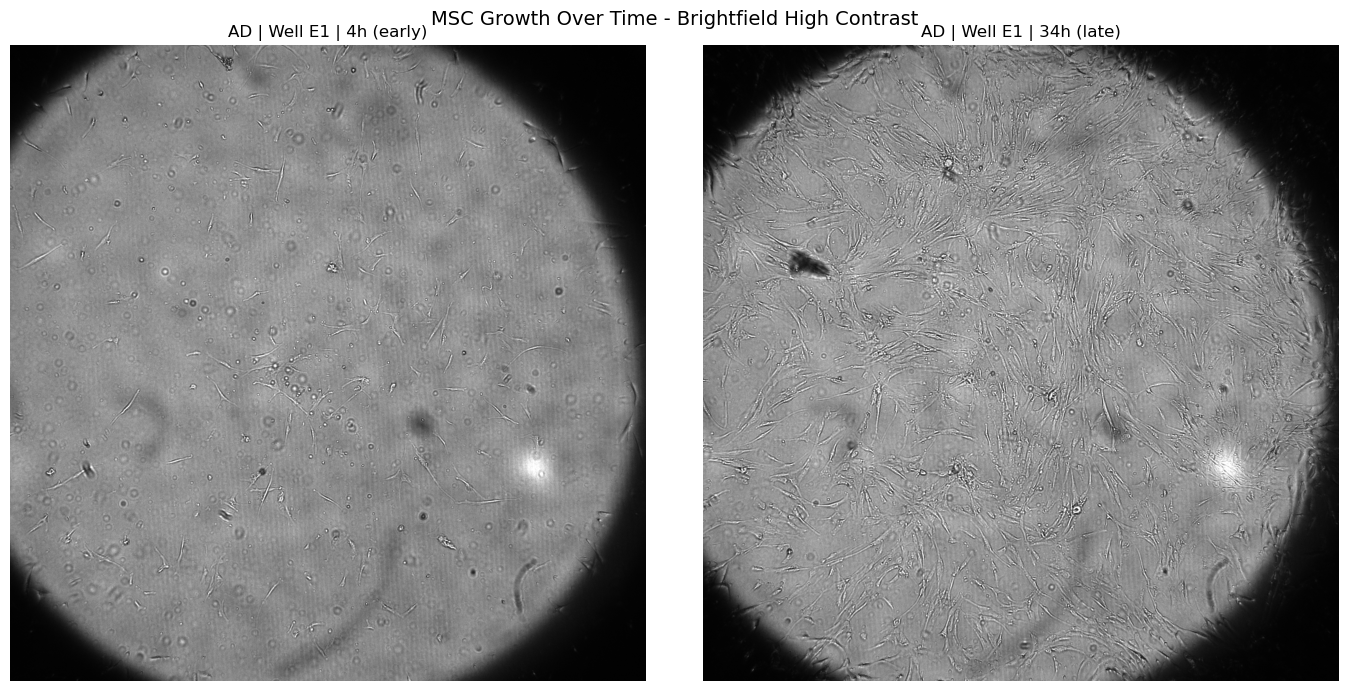

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, filename, label in zip(
    axes,
    ["AD-E1-t04.tif", "AD-E1-t34.tif"],
    ["AD | Well E1 | 4h (early)", "AD | Well E1 | 34h (late)"]
):
    img = next(x["image"] for x in images if x["filename"] == filename)
    ax.imshow(img, cmap="gray")
    ax.set_title(label, fontsize=12)
    ax.axis("off")

plt.suptitle("MSC Growth Over Time - Brightfield High Contrast", fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**

- **4h (early):** Cells are sparse and mostly suspended (round morphology with bright halo),
  with some beginning to attach and spread (elongated/spindle morphology).
  Individual cells are clearly separable — object counting is straightforward.

- **34h (late):** Cells are densely packed and predominantly adherent (spindle-shaped),
  forming overlapping clusters. Individual cell boundaries are difficult to resolve.
  At this density, confluence (% area covered) is a more reliable metric than object count.

This motivates computing **both metrics across all timepoints**: object count and 
confluence (% area covered). At low density (early timepoints), object count is reliable 
and interpretable. At high density (late timepoints), cell boundaries become difficult 
to resolve and watershed segmentation degrades — confluence becomes the more trustworthy 
indicator of proliferation.

## 2.3 Pixel Intensity Distribution

We examine how pixel intensity distributions change over time for a representative well (AD-E1).
This informs thresholding strategy: specifically, whether a global or adaptive threshold
is more appropriate given potential illumination inhomogeneity across the image.

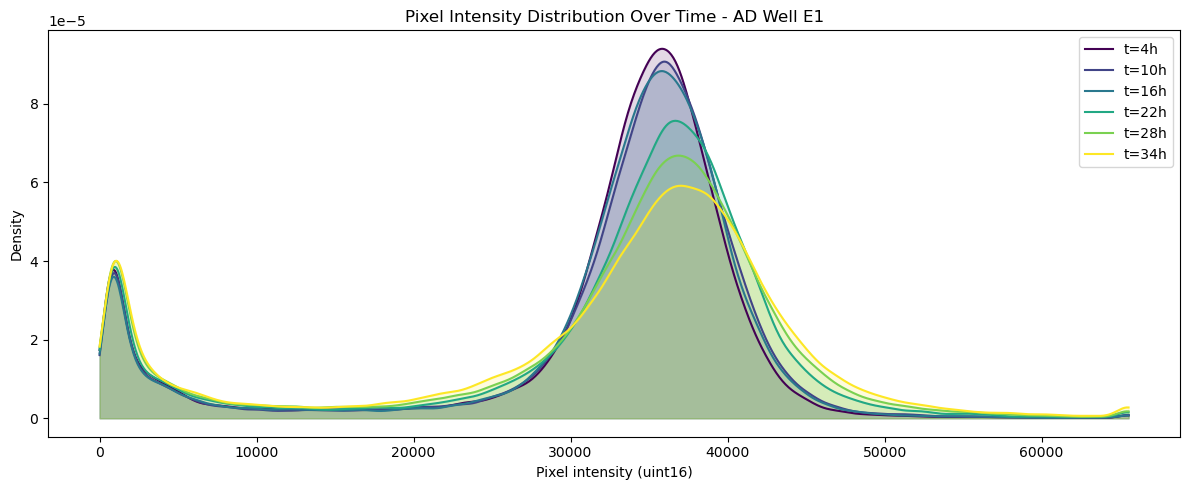

In [52]:
fig, ax = plt.subplots(figsize=(12, 5))

timepoints = [4, 10, 16, 22, 28, 34]
ad_e1 = {x["timepoint"]: x for x in images 
         if x["cell_line"] == "AD" and x["well"] == "E1"}

colors = plt.cm.viridis(np.linspace(0, 1, len(timepoints)))

for tp, color in zip(timepoints, colors):
    pixels = ad_e1[tp]["image"].flatten().astype(float)
    # Subsample for speed (KDE on 4M points is slow)
    sample = np.random.choice(pixels, size=50000, replace=False)
    kde = gaussian_kde(sample, bw_method=0.05)
    x = np.linspace(0, 65535, 1000)
    ax.plot(x, kde(x), color=color, label=f"t={tp}h", linewidth=1.5)
    ax.fill_between(x, kde(x), alpha=0.15, color=color)

ax.set_xlabel("Pixel intensity (uint16)")
ax.set_ylabel("Density")
ax.set_title("Pixel Intensity Distribution Over Time - AD Well E1")
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**

- Each image shows two pixel populations. A **bright pixel peak (~30,000–40,000)**
  corresponding to regions where light passes through freely (likely unoccupied well area),
  and a **dark pixel distribution (~0–5,000)** corresponding to light-absorbing regions
  (well boundary and cell bodies).
  - The bright pixel peak decreases in height and broadens over time. This shift becomes
  pronounced from t=22h onwards, consistent with cells progressively covering the well
  surface and reducing the proportion of unoccupied bright pixels.
  - The dark pixel distribution remains largely stable across timepoints, suggesting it
  is dominated by the fixed well boundary rather than cell pixels alone.
- The two distributions overlap substantially — motivating **adaptive thresholding**
  over a single global threshold for cell segmentation.

## 2.4 No-Growth Images

The dataset includes 4 images in which cell death occurred and no growth was observed.
We inspect these visually to understand their characteristics and justify their
exclusion from the main growth analysis.

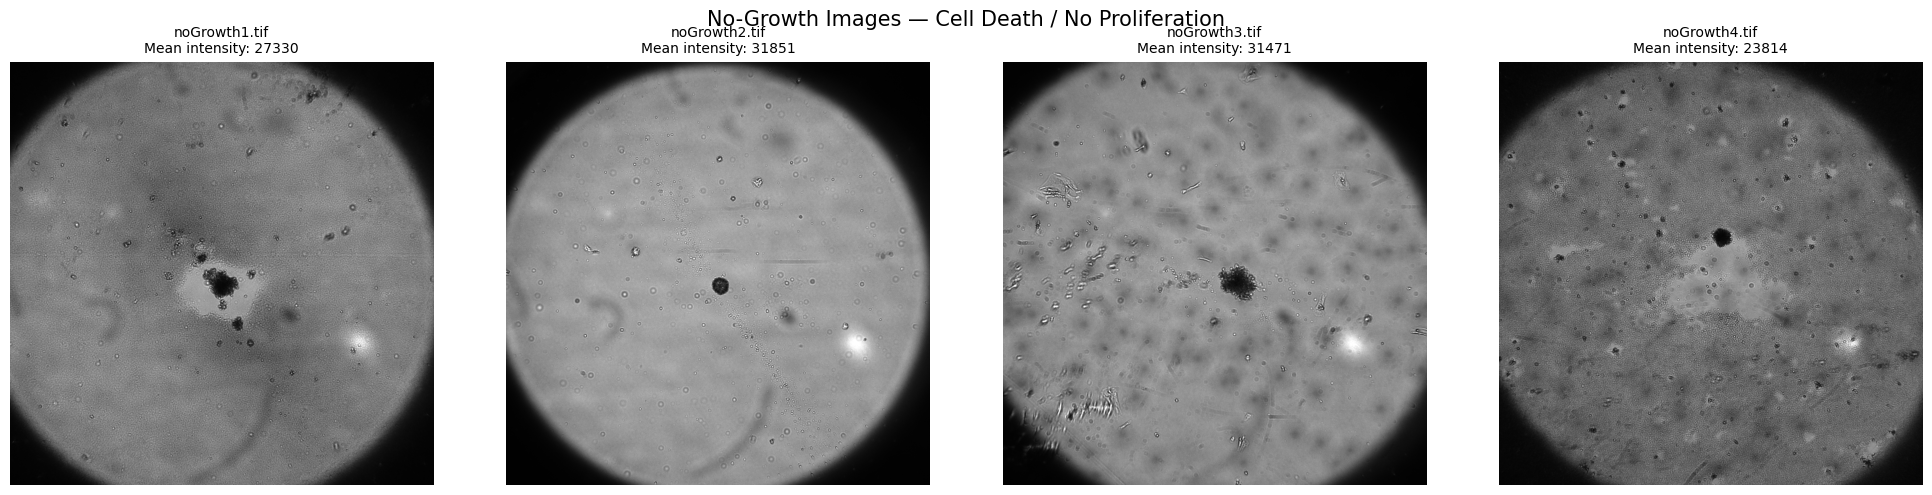

In [47]:
no_growth_images = [x for x in images if x["no_growth"]]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, x in zip(axes, no_growth_images):
    ax.imshow(x["image"], cmap="gray")
    ax.set_title(
        f"{x['filename']}\nMean intensity: {x['image'].mean():.0f}",
        fontsize=10
    )
    ax.axis("off")

plt.suptitle("No-Growth Images — Cell Death / No Proliferation", fontsize=15)
plt.tight_layout()
plt.show()

**Observations:**

- No-growth images are visually distinct from growth images: all four contain
  dark aggregates near the centre of the well, absent in normal growth images.
- noGrowth3 shows objects that superficially resemble spindle-shaped cells,
  but the overall appearance — including the dark aggregate and lack of organised
  growth pattern — is inconsistent with healthy MSC proliferation.
- Mean intensities are notably lower for noGrowth1 (27,330) and noGrowth4 (23,814)
  compared to growth images (~30,000–32,000), consistent with increased light
  absorption from debris and dead cell material.
- These images are **excluded from all growth and count analyses**.
  Applying the counting pipeline to these images would produce unreliable results,
  as the debris and aggregates do not represent viable adherent MSCs.